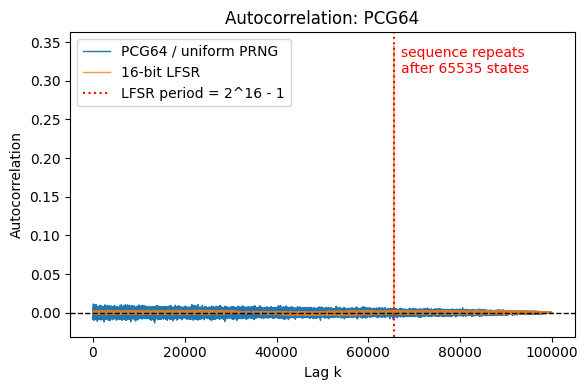

In [66]:
import numpy as np
import matplotlib.pyplot as plt

N = 100000

# NumPy's default generator (PCG64) gives the reference random sequence.
x = np.random.uniform(0, 1, N)

# A 16-bit LFSR stores its entire state in 16 binary cells.
# At each step, the register shifts by one position and a new bit is
# injected from the XOR of a few selected tap positions.
#
# Why the period is 2^16 - 1:
#   - A 16-bit register has 2^16 possible states in total.
#   - The all-zero state is absorbing: once the register is all zeros,
#     the XOR feedback also produces zero, so the sequence would never change.
#   - For a maximal-length LFSR, the feedback taps are chosen from a primitive
#     polynomial so that every nonzero state appears exactly once.
#   - That gives a cycle length of 2^16 - 1 = 65535 states, after which the
#     sequence repeats from the initial state.
def lfsr_bits(n, seed=0b1010110010101111):
    state = seed & 0xFFFF
    if state == 0:
        raise ValueError('LFSR seed must be nonzero')

    bits = np.empty(n, dtype=np.uint8)
    for i in range(n):
        # Output the least-significant bit as the current LFSR bit.
        bits[i] = state & 1
        
        # Feedback bit = XOR of selected taps.
        # This choice corresponds to a standard maximal-length 16-bit LFSR.
        feedback = ((state >> 0) ^ (state >> 2) ^ (state >> 3) ^ (state >> 5)) & 1

        # Shift right by one, then insert the new feedback bit at the top.
        state = (state >> 1) | (feedback << 15)
    return bits

# We map the LFSR output to floating-point values so the same autocorrelation code applies.
x_lfsr = lfsr_bits(N).astype(float)

def autocorrelation_from_definition(sequence):
    # Center the sequence first, then compute the normalized lag correlation.
    sequence_centered = sequence - np.mean(sequence)
    denominator = np.sum(sequence_centered ** 2)

    lags = np.arange(1, len(sequence))
    autocorrelation = np.zeros(len(lags))

    for idx, k in enumerate(lags):
        autocorrelation[idx] = np.sum(sequence_centered[:-k] * sequence_centered[k:]) / denominator

    return lags, autocorrelation

lags, autocorrelation_pcg = autocorrelation_from_definition(x)
_, autocorrelation_lfsr = autocorrelation_from_definition(x_lfsr)


plt.figure(figsize=(6, 4))
plt.plot(lags, autocorrelation_pcg, label='PCG64 / uniform PRNG', linewidth=1)
plt.plot(lags, autocorrelation_lfsr, label='16-bit LFSR', alpha=0.8, linewidth=1)
plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.axvline(2**16 - 1, color='red', linestyle=':', linewidth=1.5, label='LFSR period = 2^16 - 1')
plt.text(2**16 - 1 + 1500, 0.9 * np.max(autocorrelation_lfsr), 'sequence repeats\nafter 65535 states', color='red')
plt.title('Autocorrelation: PCG64 vs simple 16-bit LFSR')
plt.title('Autocorrelation: PCG64')
plt.xlabel('Lag k')
plt.ylabel('Autocorrelation')
plt.tight_layout()
plt.legend()
plt.show()